# Welcome to the OnSSET Notebook

This Jupyter based interface is built on the [OnSSET](http://www.onsset.org/) tool developed to provide an easy and quick way to generate electrification investment scenarios.

#### Start by importing the code 

In [1]:
from onsset import *
from IPython.display import display, Markdown, HTML
%matplotlib inline
%run funcs.ipynb
%run detailed_tech_parameters.ipynb
import warnings
import os
warnings.filterwarnings('ignore')
import time
import matplotlib.pylab as plt
import seaborn as sns
from onsset.climate_algorithm import process_climate_data

c:\Users\sondrmsk\Code\ClimateOnSSET\onsset\__init__.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


### 1. GIS data selection

First, run the cell below to browse to the directory your input CSV file is located at and select the input file. 

In [2]:
input_file   = "climate_example_workflow_niger/OnSSET_InputFile_Calibrated.csv"
pv_path      = "climate_example_workflow_niger/ne-2-pv.csv"
wind_path    = "climate_example_workflow_niger/ne-2-wind.csv"
existing_mv  = "climate_example_workflow_niger/niger-electricity-transmission-network.zip"

# Climate inputs — only used when prio_choice == 6
# climate_folder=None means cached per-hazard CSVs are loaded; raw climate data
# is NOT reprocessed. The cache (e.g. heatwave_hazard.csv, drought_hazard.csv) is
# only invalidated by manual deletion. To recompute hazards, set climate_folder to
# a raw-climate-data directory and delete the cached CSV files first.
admin3_shapefile           = "climate_example_workflow_niger/gadm41_NER_3.shp"
precomputed_hazards_folder = "onsset/climate_calculations/precomputed_hazards/"
climate_folder             = None

output_dir = "results/"
os.makedirs(output_dir, exist_ok=True)

In [3]:
onsseter = SettlementProcessor(input_file)
onsseter.conditioning()

In [4]:
x_mv_exist, y_mv_exist = onsseter.start_extension_points(existing_mv)
x_coordinates = x_mv_exist
y_coordinates = y_mv_exist

# 2. Modelling period and target electrification rate

Next, define the modelling period and the electrification rate to be achieved by the end of the analysis. Further down you will also define an intermediate year and target.

In [5]:
start_year = 2025  # This should be the same as in the calibration file
end_years = [2030, 2035, 2040] # Write all the years you want the results for

end_electrification_rate_target = {2030: 0.5, 2035: 0.7, 2040: 1} # Write the target electricity access rate for each of the end years in the following format {2030: 0.9, 2035: 1} 

yearsofanalysis = end_years
eleclimits = end_electrification_rate_target
time_steps = {}
for i in range(len(end_years)):
    if i == 0:
        time_steps[end_years[i]] = end_years[i] - start_year
    else:
        time_steps[end_years[i]] = end_years[i] - end_years[i-1]

# 3. Enter country specific data

To run scenarios, the user can customize a large number of variables describing the social - economic - technological environment in the selected country. 

### a. Demographics and Social components

In [6]:
end_year_pop = 42300000
         ### Write the expected population in the END year (e.g. 2030) 

urban_ratio_end_year = 0.21     ### Write the urban population population ratio in the END year (e.g. 2030)

num_people_per_hh_urban = 5.9     ### Write the number of people per household in urban areas
num_people_per_hh_rural = 5.8   ### Write the number of people per household in rural areas

### b. Technology specifications & costs

The cell below contains all the information that is used to calculate the levelized costs for all the technologies, including grid. These default values should be updated to reflect the most accurate values in the country. There are currently 6 potential technologies to include in the model:
 * Grid
 * 
PV Hybrid Mini-grid
 * Wind Mini-grid
 * Hydro Mini-grid
 * PV Stand-alone systems
 * Diesel stand-alone systems

The key technology input parameters can be defined below. More detailed parameters for each technology can be found and edited in the **detailed_tech_parameters** notebook.

#### Centralized grid parameters 

In [7]:
grid_generation_cost = 0.10                ### This is the grid cost electricity USD/kWh as expected in the end year of the analysis
grid_power_plants_capital_cost = 1303      ### The cost in USD/kW is for capacity upgrades of the grid
grid_losses = 0.27                         ### The fraction of electricity lost in transmission and distribution (percentage)
grid_emission_factor = 745                 ### This is the average emissions from grid generation (gCO2/kWh), see e.g. https://unfccc.int/documents/461676

annual_new_grid_connections_limit = 99999999 # This is the maximum amount of new households that can be connected to the grid in one year
annual_grid_cap_gen_limit = 9999999        # This is the maximum generation capacity (MW) that can be added to the grid in one year

In [8]:
# Grid Transmission and distribution costs
hv_line_capacity=110 # kV
hv_line_cost=106000 # USD/km

grid_mv_line_capacity=33 # kV
grid_mv_line_cost=25000 # USD/kW
grid_mv_line_max_length=150 # km
grid_MV_line_amperage_limit = 275  # Ampere (A)

grid_lv_line_capacity=0.4 #kV
grid_lv_line_max_length=1 # km
grid_lv_line_cost=15000 # USD/km

grid_service_Transf_type=75  # kVA
grid_service_Transf_cost=9000  # $/unit
grid_max_nodes_per_serv_trans=95  # maximum number of nodes served by each service (MV/LV) transformer

hv_mv_transformer_type = 16000 #kVA
hv_mv_transformer_cost = 980000 # USD/unit

#### Off-grid technology parameters

In [9]:
min_mg_size = 100             # Minimum number of households in a settlement for mini-grids to be considered
mg_min_grid_dist = 0          # Minimum distance from existing MV lines for mini-grids to be considered as an option

In [10]:
diesel_price = 1.4                   ### This is the diesel price in USD/liter as expected in the end year of the analysis

In [11]:
# PV and Wind hybrid mini-grid costs
pv_cost = 1400                      # PV panel costs including BoS (PV inverter, charge controller) (USD/kW)
battery_cost = 550                 # battery capital cost, USD/kWh of storage capacity                    
inverter_cost  = 598             # Battery inverter, USD/kW
diesel_gen_cost = 500              # diesel generator capital cost, USD/kW rated power
wind_cost = 2500                   # Wind turbine capital cost, USD/kW peak power

inverter_life=20    # Battery inverter expected lifetime in mini-grid, years
diesel_life=20      # diesel generator expected lifetime in mini-grid, years
pv_life=25          # PV panel expected lifetime in mini-grid, years
        
lpsp_max=0.10         # maximum loss of load allowed over the year, in share of kWh (e.g. 0.1 means that the mini-grid will be able to meet at least 90% of the demand over the year)
max_diesel = 0.5     # Maximum share of generation that can come from diesel generators (0-1). Set to 0 for fully renewable mini-grids

In [12]:
mg_hydro_capital_cost = {float("inf"): 15000}      ### Mini-grid Hydro capital cost (USD/kW) as expected in the years of the analysis

In [13]:
# Mini-grid distribution network spcification

mg_mv_line_capacity=33 # kV
mg_mv_line_cost = 25000 # USD/kW
mg_MV_line_amperage_limit = 275  # Ampere (A)

mg_lv_line_capacity=0.4 #kV
mg_lv_line_max_length=1 # km
mg_lv_line_cost=15000 # USD/km

mg_service_Transf_type=75  # kVA
mg_service_Transf_cost=9000  # $/unit
mg_max_nodes_per_serv_trans=95  # maximum number of nodes served by each service (MV/LV) transformer

In [14]:
sa_pv_capital_cost_1 = 11600          ### Solar Home System capital cost (USD/kW) for household systems under 20 W
sa_pv_capital_cost_2 = 7500          ### Solar Home System capital cost (USD/kW) for household systems between 21-50 W
sa_pv_capital_cost_3 = 7500           ### Solar Home System capital cost (USD/kW) for household systems between 51-100 W
sa_pv_capital_cost_4 = 8000           ### Solar Home System capital cost (USD/kW) for household systems between 101-1000 W
sa_pv_capital_cost_5 = 8000           ### Solar Home System capital cost (USD/kW) for household systems over 1 kW

shs_lifetime = 5                      ### Expected technology lifetime of Solar Home System

The cells below contain additional technology specifications

In [15]:
grid_discount_rate = 0.12 # E.g. 0.08 means a discount rate of 8%
mini_grid_discount_rate = 0.12
standalone_discount_rate = 0.12

### c. Electricity demand target

For the second lever, enter the target tier (level of electricity access) for urban and rural households respectively. This can take a value between "1" (lowest level of electricity access) and "5" (highest level of electricity access) as in ESMAPs Multi-Tier Framework for Measuring Electricity Access (found <a href="https://www.esmap.org/node/55526" target="_blank">here</a>). Alternatively, enter "6" to use a distribution of the tiers across the country based on poverty levels and GDP according to the methodology found <a href="https://www.mdpi.com/1996-1073/12/7/1395" target="_blank">here</a>.   

*On the GEP Explorer, the following three electricity demand targets are used:*

*Top down demand target - Low: In this case, all urban clusters are tergeted to reach the current average consumption level of electrified households, and rural settlements are assigned Tier 1.* 

*Top down demand target - High: In this case, all urban clusters are tergeted to reach one Tier higher than the current average consumption level of electrified households, and rural settlements are assigned Tier 3.*

*Bottom up demand target (Poverty - GDP): In this case each settlement is assigned a demand target based on poverty and GDP levels as described in the methodology above. Choose "6" for both the urban_target_tier and rural_target_tier to use this option* 

In [16]:
# Define the annual household electricity targets to choose from
tier_1 = 20  # 43 refers to kWh/household/year. 
tier_2 = 73
tier_3 = 365
tier_4 = 1241
tier_5 = 3000

In [17]:
rural_cutoff_size = 100  # Any rural settlement with fewer households is considered a "small rural" settlement, rural settlements with larger population is considered "large rural" 

urban_target_tier = 3               # Target demand Tier for Urban settlements
rural_target_tier_large = 3         # Target demand Tier for large rural settlements
rural_target_tier_small = 3         # Target demand Tier for small rural settlements

In [18]:
productive_demand = 0                     # 1 if productive demand is defined and should be included, else 0

### d. Rollout plan
This lever reflects the electrification approach to be examined. On the GEP Explorer, there are currently two options in use:

**Nationwide Least Cost approach:** This options aims to achieve the electrification rate targets set for the intermediate and end year. For the years where the target is set below 100%, the algorithm prioritizes grid densification first (ramp up in already electrified clusters) then selection based on lowest invetsment cost per capita to choose which clusters to be electrified.

**Forced grid approach:** Forced grid under a defined buffer zone (auto_intensification set equal to X km) & least cost approach outside of the buffer zone.

In [19]:
auto_intensification = 2        # Buffer distance (km) for automatic intensification

max_grid_intensification_cost = 99999999999999  # Maximum cost per household (USD/household) for forced grid intensification 

If using a target access rate less than 100%, choose how to select which settlements to electrify first. The options are:
* 1 = Select the most easily reached settlements first, based on lowest distance to main roads
* 2 = Select the most easily reached settlements, based on travel time
* 3 = Select the largest settlements first
* 4 = Select settlements based on the lowest investment cost per capita (low demand settlements first)
* 6 = Select settlements based on the highest climate risk profiles first

In [20]:
prio_choice = 6       # Select 1, 2, 3 or 4 as described above 

In [21]:
if prio_choice == 6:
    if climate_folder is None and not os.path.exists(precomputed_hazards_folder):
        raise RuntimeError(
            "prio_choice == 6 requires either climate_folder (raw data) or a populated "
            "precomputed_hazards_folder. Set one in the User-editable paths cell above."
        )
    print("Processing climate data...")
    onsseter.df = process_climate_data(
        climate_folder=climate_folder,
        admin3_shapefile=admin3_shapefile,
        settlements_df=onsseter.df,
        specs_path=None,
        precomputed_hazards_folder=precomputed_hazards_folder,
    )
    print("Climate data processing complete.")
else:
    print(f"Skipping climate data load (prio_choice = {prio_choice}, not 6).")

2026-05-30 17:13:48,649		============================================================
2026-05-30 17:13:48,651		Starting climate data processing...
2026-05-30 17:13:48,651		============================================================
2026-05-30 17:13:48,651		Using default climate configuration values
2026-05-30 17:13:48,651		Using cached hazard for drought from onsset/climate_calculations/precomputed_hazards/drought_hazard.csv
2026-05-30 17:13:48,651		Using cached hazard for heatwave from onsset/climate_calculations/precomputed_hazards/heatwave_hazard.csv
2026-05-30 17:13:48,651		Loading admin-3 shapefile: climate_example_workflow_niger/gadm41_NER_3.shp
2026-05-30 17:13:48,668		Loaded 131 admin-3 regions
2026-05-30 17:13:48,668		Loading cached hazard CSV for drought: onsset/climate_calculations/precomputed_hazards/drought_hazard.csv
2026-05-30 17:13:48,668		Loading cached hazard CSV for heatwave: onsset/climate_calculations/precomputed_hazards/heatwave_hazard.csv


Processing climate data...


2026-05-30 17:13:49,501		Mapped climate risk to 328090 settlements
2026-05-30 17:13:49,584		============================================================
2026-05-30 17:13:49,584		Climate data processing complete.
2026-05-30 17:13:49,599		============================================================


Climate data processing complete.


# 5. Start a scenario run, which calculate and compare technology costs for every settlement in the country

Based on the previous calculation this piece of code identifies the LCoE that every off-grid technology can provide, for each single populated settlement of the selected country. The cell then takes all the currently grid-connected points in the country, and looks at the points within a certain distance from them, to see if it is more economical to connect them to the grid, or to use one of the off-grid technologies calculated above. Once more points are connected to the grid, the process is repeated, so that new points close to those points might also be connected. This is repeated until there are no new points to connect to the grid.

In [22]:
grid_calc, mg_pv_hybrid_calc, mg_wind_hybrid_calc, mg_hydro_calc, sa_pv_calc, sa_diesel_calc, mg_pv_hybrid_params, mg_wind_hybrid_params, mg_diesel_params, mg_interconnection, grid_reliability_option, cnse, grid_reliability = init_tech_info(grid_losses, grid_power_plants_capital_cost, grid_generation_cost, grid_discount_rate, grid_mv_line_capacity,
                   grid_MV_line_amperage_limit, grid_mv_line_cost, grid_lv_line_capacity, grid_lv_line_cost, grid_lv_line_max_length, 
                   grid_service_Transf_type, grid_service_Transf_cost, grid_max_nodes_per_serv_trans,
                   mini_grid_discount_rate, mg_mv_line_capacity, mg_MV_line_amperage_limit, mg_mv_line_cost, mg_lv_line_capacity, 
                   mg_lv_line_cost, mg_lv_line_max_length, mg_service_Transf_type, mg_service_Transf_cost, mg_max_nodes_per_serv_trans,
                   mg_hydro_capital_cost, shs_lifetime, standalone_discount_rate, sa_pv_capital_cost_1, sa_pv_capital_cost_2, sa_pv_capital_cost_3, 
                   sa_pv_capital_cost_4, sa_pv_capital_cost_5, min_mg_size, diesel_gen_cost, battery_cost, pv_life, diesel_life, inverter_cost,
                   inverter_life, lpsp_max, max_diesel, diesel_price)

onsseter.df, new_lines_geojson = run_scenario(onsseter, end_year_pop, urban_ratio_end_year, start_year, end_years[-1], yearsofanalysis, x_coordinates, y_coordinates, tier_1, 
                 tier_2, tier_3, tier_4, tier_5, hv_line_capacity, hv_line_cost, hv_mv_transformer_cost, hv_mv_transformer_type, eleclimits, time_steps, 
                 annual_new_grid_connections_limit, annual_grid_cap_gen_limit, num_people_per_hh_urban, num_people_per_hh_rural, urban_target_tier, 
                 rural_target_tier_large, rural_target_tier_small, rural_cutoff_size, mg_diesel_params, mg_wind_hybrid_params, wind_path, 
                 mg_pv_hybrid_params, pv_path, mg_hydro_calc, mg_wind_hybrid_calc, sa_pv_calc, mg_pv_hybrid_calc, min_mg_size, mg_min_grid_dist,
                 grid_generation_cost, grid_calc, sa_diesel_calc, max_grid_intensification_cost, auto_intensification, grid_mv_line_max_length, 
                 mg_interconnection, grid_reliability_option, cnse, grid_reliability, prio_choice, grid_emission_factor)

finalize_results(onsseter, yearsofanalysis)

2026-05-30 17:13:49,603		Population projection process
2026-05-30 17:13:49,742		Populate ResidentialDemandTier columns
2026-05-30 17:13:49,746		Determine current MV line length


Starting Sat May 30 17:13:49 2026


2026-05-30 17:13:49,837		Calculate new connections
2026-05-30 17:13:49,855		Setting electrification demand as per target per year
2026-05-30 17:13:50,017		Starting wind hybrid gen lcoe


Optimize Wind Hybrid Systems Sat May 30 17:13:50 2026


2026-05-30 17:14:13,342		Starting hybrid gen lcoe


...

Sat May 30 17:19:02 2026 Calculating off-grid investment cost for year 2040
Calculate Grid LCOEs Sat May 30 17:19:02 2026
Sat May 30 17:19:04 2026 Calculate grid extension for year 2040
3975  new settlements connected to the grid Sat May 30 17:19:07 2026
548  new settlements connected to the grid Sat May 30 17:19:07 2026
98  new settlements connected to the grid Sat May 30 17:19:08 2026
25  new settlements connected to the grid Sat May 30 17:19:08 2026
8  new settlements connected to the grid Sat May 30 17:19:09 2026


2026-05-30 17:19:10,852		Determine minimum overall tech
2026-05-30 17:19:10,917		Determine minimum overall LCOE


Calculating results columns Sat May 30 17:19:10 2026


2026-05-30 17:19:11,044		Calculate investment cost
2026-05-30 17:19:11,061		Calculate new capacity
2026-05-30 17:19:11,098		Determine electrification limits
2026-05-30 17:19:11,104		Determine final electrification decision


The electrification rate achieved in 2040 is 100.0 %



# 6. Results, Summaries and Visualization
With all the calculations and grid-extensions complete, this block gets the final results on which technology was chosen for each point, how much capacity needs to be installed and what it will cost. Then the summaries, plots and maps are generated.

In [23]:
techs = ["Grid", "SA_PV", "MG_PVHybrid", "MG_Wind", "MG_Hydro"]
tech_codes = [1, 3, 5, 6, 7]

summary_table, columns = calc_summary_table(onsseter.df, yearsofanalysis)
display(Markdown('### Summary \n These are the summarized results of the selected country'))
summary_table

### Summary 
 These are the summarized results of the selected country

,Population2030,NewConnections2030,Capacity2030 (MW),Investment2030 (million USD),Emissions2030 (tCO2),Population2035,NewConnections2035,Capacity2035 (MW),Investment2035 (million USD),Emissions2035 (tCO2),Population2040,NewConnections2040,Capacity2040 (MW),Investment2040 (million USD),Emissions2040 (tCO2),PopulationTotal,NewConnectionsTotal,CapacityTotal (MW),InvestmentTotal (million USD),EmissionsTotal (tCO2)
Grid_dens,20359,429,0.05,1.01,0.12,23257,494,0.06,1.22,0.13,26567,561,0.06,1.29,0.15,26567,1484,0.17,3.52,0.4
Grid_ext,9575100,1638563,187.05,2979.69,445.57,14892998,905090,103.32,1561.11,246.12,28125414,2249961,256.84,3982.39,611.82,28125414,4793614,547.21,8523.19,1303.51
SA_PV,3224309,537641,96.87,1549.88,0.00,5516746,382112,69.40,1105.62,0.00,7849067,390178,70.26,1115.43,0.00,7849067,1309931,236.53,3770.93,0.0
MG_PV_Hybrid,2854319,483789,86.90,901.95,599.19,5043020,370990,63.72,714.38,382.25,6298949,212817,37.72,430.39,154.71,6298949,1067596,188.34,2046.72,1136.15
MG_Wind,0,0,0.00,0.00,0.00,0,0,0.00,0.00,0.00,0,0,0.00,0.00,0.00,0,0,0.0,0.0,0.0
MG_Hydro,0,0,0.00,0.00,0.00,0,0,0.00,0.00,0.00,0,0,0.00,0.00,0.00,0,0,0.0,0.0,0.0
Non-electrified,15724206,0,0.00,0.00,0.00,11005119,0,0.00,0.00,0.00,0,0,0.00,0.00,0.00,0,0,0.0,0.0,0.0
Total,31398293,2660422,370.87,5432.53,1044.88,36481140,1658686,236.50,3382.33,628.50,42299997,2853517,364.88,5529.50,766.68,42299997,7172625,972.25,14344.36,2440.06


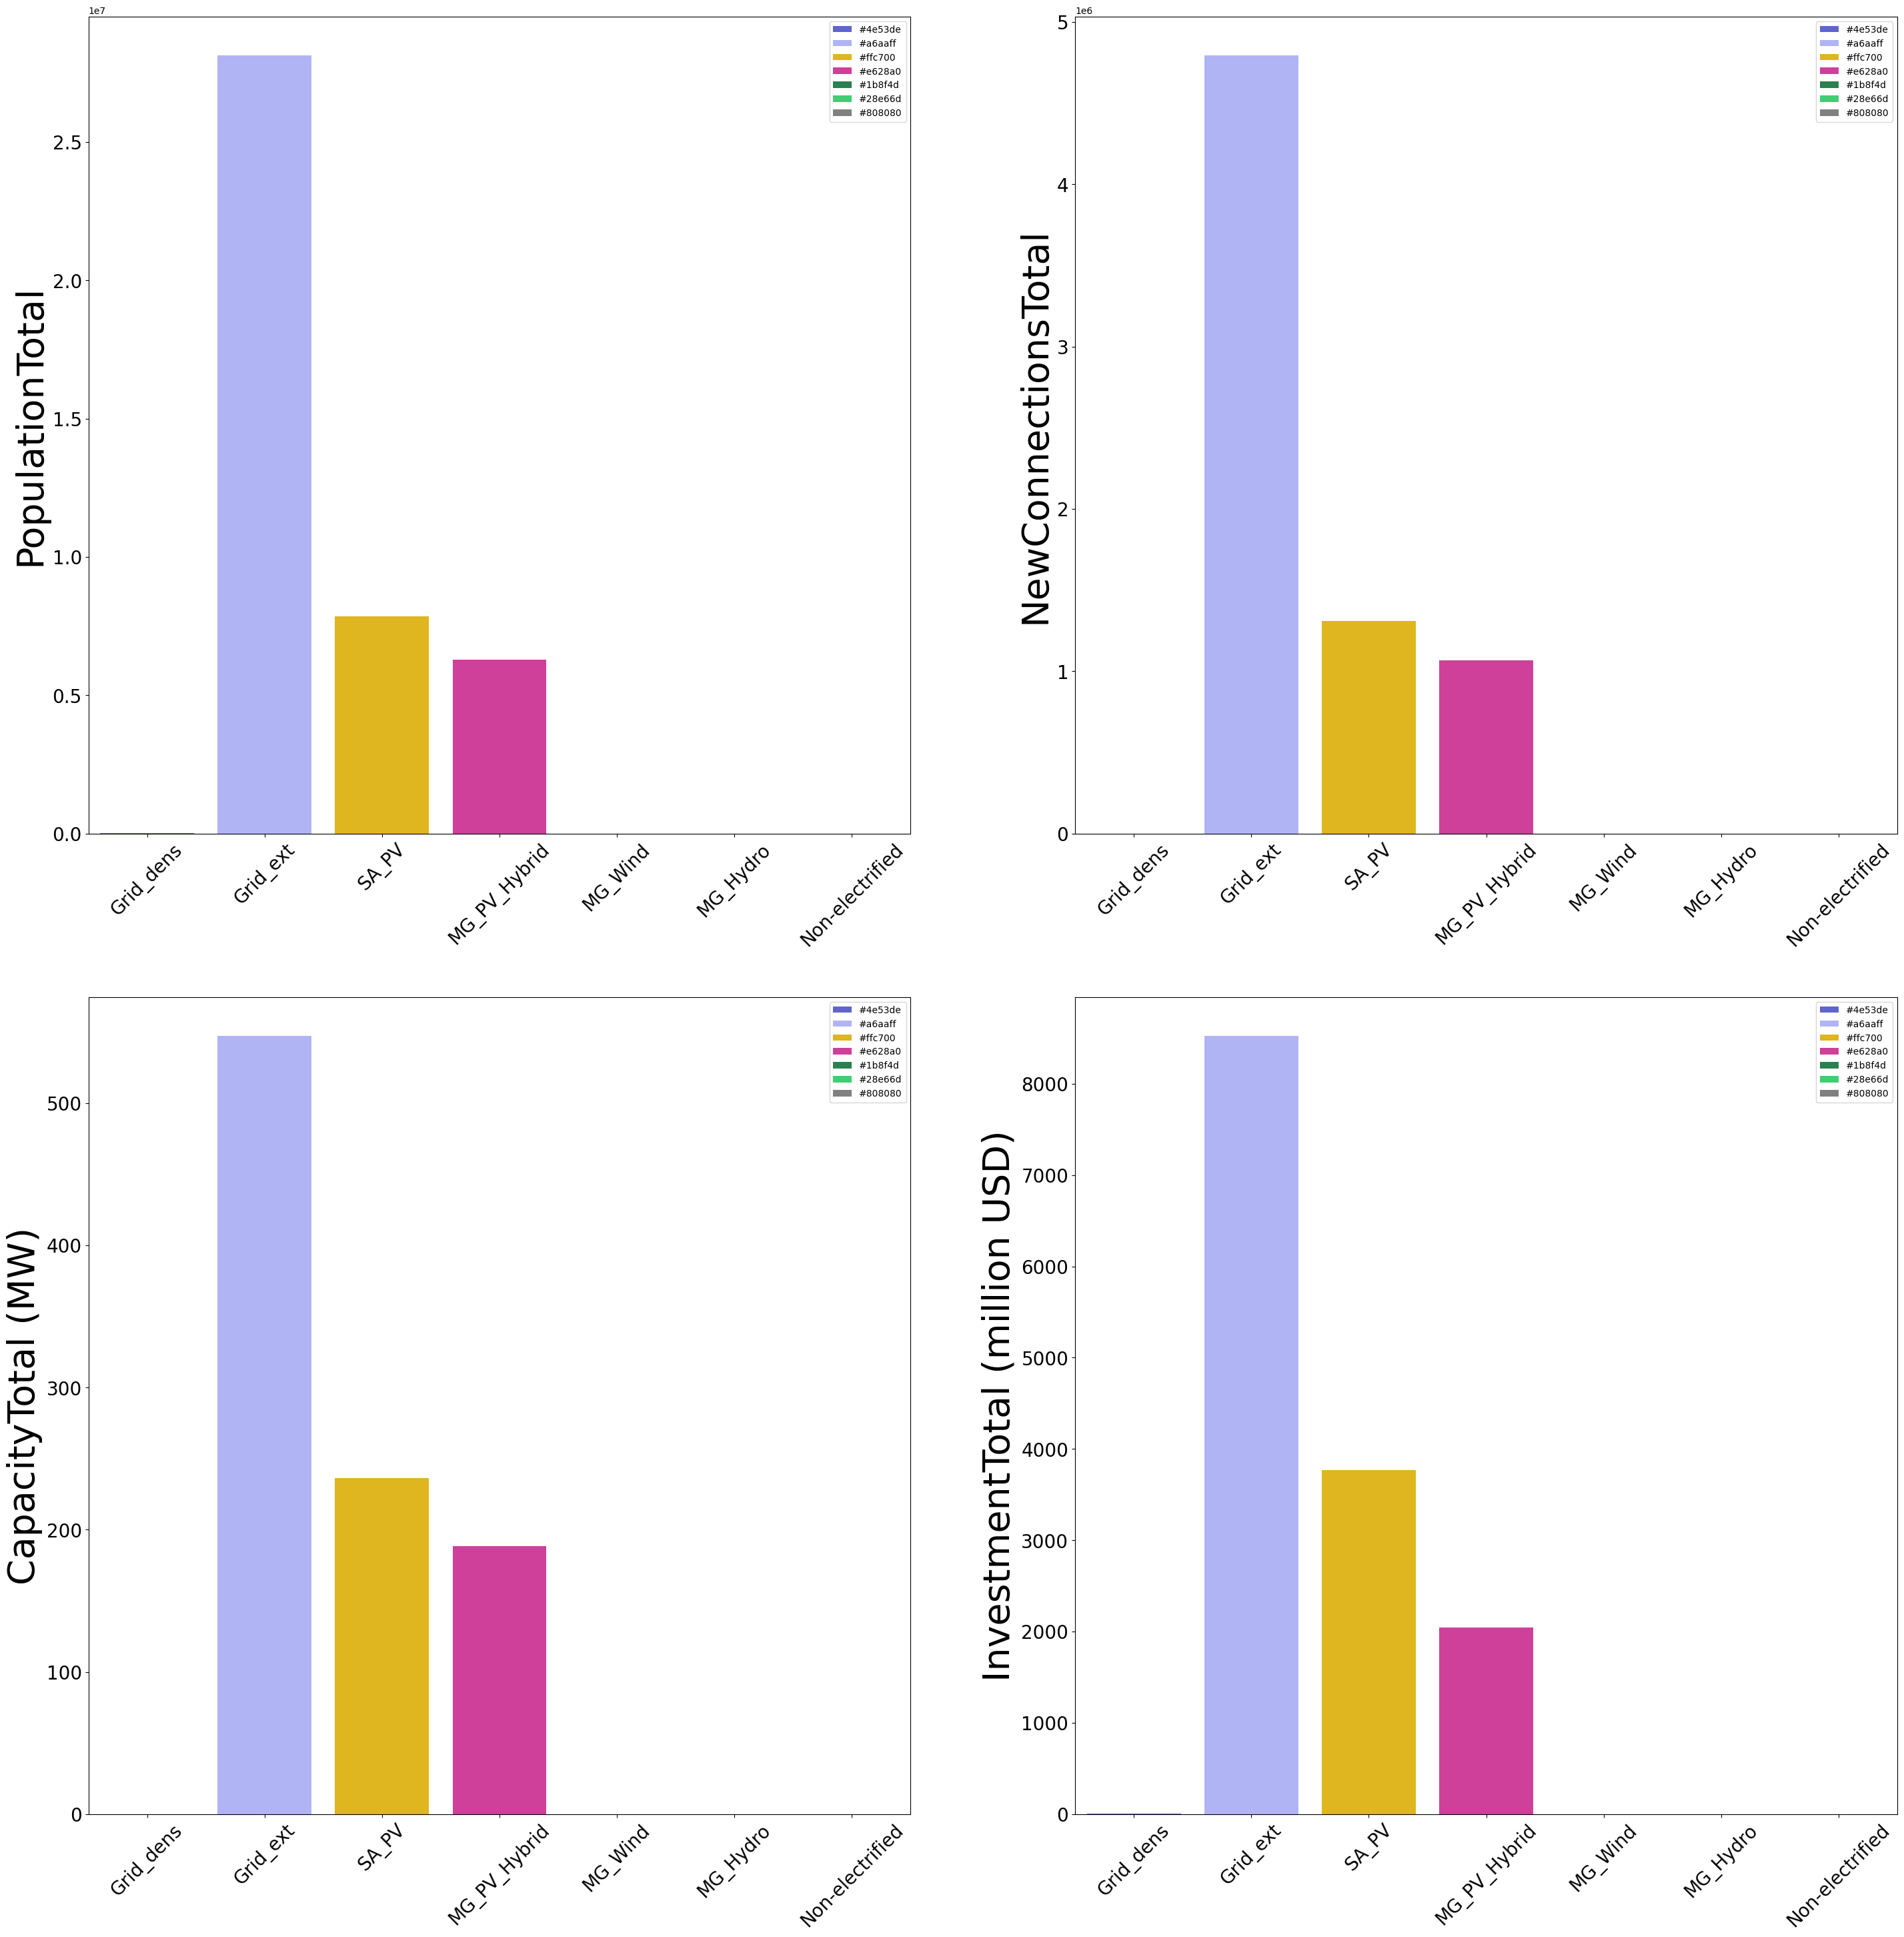

In [24]:
bar_plot(summary_table, columns, yearsofanalysis, techs)

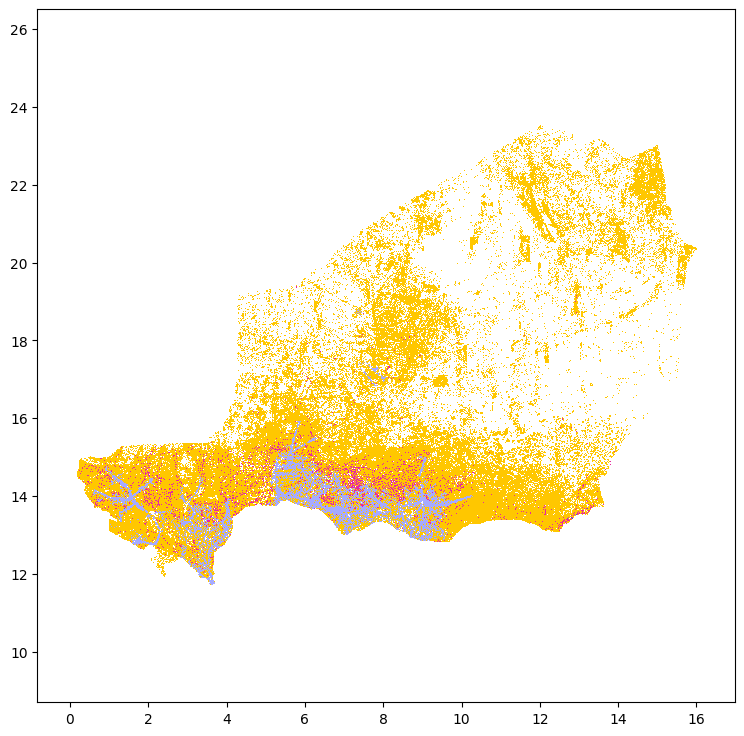

<Figure size 3000x3000 with 0 Axes>

Number of new PV Hybrid mini-grid locations:  3369


In [25]:
map_plot(onsseter.df, yearsofanalysis[-1], start_year)

## 7. Exporting results

This code generates three csv files:
 - one containing all the results for the scenario created
 - one containing the summary for the scenario created
 - one containing some if the key input variables of the scenario

Before we proceed, please write the scenario_name in the first cell below. then move on to the next cell and run it to browse to the directory where you want to save your results. Sample file shall be located at .\ gep-onsset\sample_output. 

**Note that if you do not change the scenario name, the previous output files will be overwritten**

In [ ]:
scenario_name = "test_multiple"

In [ ]:
output_dir_variables = os.path.join(output_dir, "{}_Variables.csv".format(scenario_name))
output_dir_results = os.path.join(output_dir, "{}_Results.csv".format(scenario_name))
output_dir_summaries = os.path.join(output_dir, "{}_Summaries.csv".format(scenario_name))

In [28]:
df_variables = save_variables(onsseter, start_year, yearsofanalysis, end_electrification_rate_target, urban_target_tier, rural_target_tier_large,
                              rural_target_tier_small, auto_intensification, max_grid_intensification_cost, end_year_pop, urban_ratio_end_year,
                              grid_generation_cost, grid_power_plants_capital_cost, grid_losses, diesel_price, mg_hydro_capital_cost, min_mg_size,
                              mg_min_grid_dist, mg_interconnection, pv_cost, battery_cost, inverter_cost, diesel_gen_cost, max_diesel, 
                              sa_pv_capital_cost_1, sa_pv_capital_cost_2, sa_pv_capital_cost_3, sa_pv_capital_cost_4, sa_pv_capital_cost_5, 
                              grid_mv_line_cost, grid_lv_line_cost, grid_mv_line_capacity, grid_lv_line_capacity, grid_lv_line_max_length, hv_line_cost, 
                              grid_mv_line_max_length, annual_new_grid_connections_limit, annual_grid_cap_gen_limit, grid_discount_rate, 
                              mini_grid_discount_rate, standalone_discount_rate)

# Returning the summary as a csv file
summary_table.to_csv(output_dir_summaries, index=True)

# Returning the input variables as a csv file
df_variables.to_csv(output_dir_variables, index=False)

In [29]:
# Returning the full result as a csv file
onsseter.df.to_csv(output_dir_results, float_format="%.4f", index=False)

In [30]:
# Saving the new MV lines as a geojson file

for year in yearsofanalysis:
    try:
        try:
            os.remove(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
        except FileNotFoundError:
            pass
        with open(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)), 'w') as f:
            geojson.dump(new_lines_geojson[year], f)
        gdf = gpd.read_file(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
        gdf = gdf.set_crs(3395, allow_override=True)
        gdf = gdf.to_crs(4326)
        gdf.to_file(os.path.join(output_dir, 'new_mv_lines_{}_{}.geojson'.format(scenario_name, year)))
    except Exception as e:
        print(year, e)

2026-05-30 17:19:56,241		Created 15,382 records
2026-05-30 17:19:56,618		Created 4,876 records
2026-05-30 17:19:57,206		Created 9,308 records
